## Introduction

In this project, we are going to use machine learning methods to analyze and classify the churn data. Project has 4 sections.

1- Defining the problem            
2- Data         
3- Evaluation of the model                      
4- Features 
5- Financial Analysis

## 1-Defining the Problem

Customer churn data received from Kaggle (previously IBM) will be used for classification problem. In this project we will use a machine learning algorithm to predict the customer whether continue using the company service or not. We will apply to forecast the customer choice and then provide the important features according to selected algoritm.

## 2-Data
Data is consisted of 33 different variables and 7043 observation. We will investigate the data, get rid off some variables those are not usefull.

CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Country: The country of the customer’s primary residence.

State: The state of the customer’s primary residence.

City: The city of the customer’s primary residence.

Zip Code: The zip code of the customer’s primary residence.

Lat Long: The combined latitude and longitude of the customer’s primary residence.

Latitude: The latitude of the customer’s primary residence.

Longitude: The longitude of the customer’s primary residence.

Gender: The customer’s gender: Male, Female

Senior Citizen: Indicates if the customer is 65 or older: Yes, No

Partner: Indicate if the customer has a partner: Yes, No

Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

Tenure Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

Phone Service: Indicates if the customer subscribes to home phone service with the company: Yes, No

Multiple Lines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

Internet Service: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

Online Security: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

Online Backup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

Device Protection: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

Tech Support: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

Streaming TV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Streaming Movies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

Paperless Billing: Indicates if the customer has chosen paperless billing: Yes, No

Payment Method: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.

Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

Churn Label: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

Churn Value: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

Churn Score: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

CLTV: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

Churn Reason: A customer’s specific reason for leaving the company. Directly related to Churn Category.

In [1]:
# Let's import related libraries to restructure and clean the data
import pandas as pd
import numpy as np

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
raw_data=pd.read_excel("Telco_customer_churn.xlsx")
raw_data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


#### In the Data section we will do 3 things
#### - First we will simplify the data. The data has several columns and not all of them provide sufficient information
#### - Second we will transform the data to suitable format for ML algorithms.
#### - Finally we will make EDA on cleaned/transformed version of the data

In [3]:
""" First of all we have to drop Churn Label, Churn Score, CLTV, Churn Reason columns because we are trying to predict the customer's decision
These variables can increase the prediction performance but it will be cheating if we use these so first we will be getting rid of these variables.
""" 

data=raw_data.drop(["Churn Label", "Churn Score", "CLTV", "Churn Reason"], axis=1)
data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [4]:
# Next thing we are going to do is figuring out which columns/variables have single value

un_col=[col for col in data.columns if data[col].nunique()==1]
print(un_col)

['Count', 'Country', 'State']


In [5]:
# These columns has a single value so they will not be providing any information
data.drop(un_col, axis=1, inplace=True)

In [6]:
## As far as I can see, Customer Id will not going to provide us any information and also, also Lat Long column is not needed becasue
## there are Latitude and Longitude columns (geographic values of customer) has the same value
d_col=["Lat Long", "CustomerID"]
data.drop(d_col, axis=1, inplace=True)

In [7]:
# Also Zip Code, Latitude and Longitude  columns provide the same data but keeping zip code column may create problems so
# we will get rid of Zip Code column, city has also gives the same information so getting rid of that column also usefull for simplicity

data = data.drop(columns=["Zip Code", "City"])

In [8]:
# There are blank cells in Total Charges column so we have to change them

data["Total Charges"] = pd.to_numeric(raw_data["Total Charges"], errors="coerce")
data["Total Charges"] = data["Total Charges"].fillna(0)

In [9]:
## There are columns that has "no internet service" and "no phone service" changing them to no is a logical choice

replace_cols = [ "Online Security", "Online Backup", "Device Protection", 
                "Tech Support","Streaming TV", "Streaming Movies"]

for col in replace_cols:
    data[col] = data[col].replace({"No internet service": "No"})

data["Multiple Lines"] = data["Multiple Lines"].replace({"No phone service": "No"})

In [10]:
## There are some customers that has 0 tenur months, these are the new customers and they will not give us sufficient info
## so we have to let them go

data = data[data["Total Charges"] != 0]

#### Previously we get rid of some info in our data, from now we will transform the data to numerical values 

In [11]:
## We will change the yes/no values to 0-1 and also we will make the same thing to columns has binary values (Only gender column it seems)

bin_col = [col for col in data.columns if data[col].nunique() == 2]
for col in bin_col:
    
    if "Yes" in data[col].values or "No" in data[col].values:
        data[col] = data[col].map({"Yes": 1, "No": 0})


if 'Gender' in data.columns:
    data["Gender"] = data["Gender"].map({"Female": 0, "Male": 1})

In [12]:
## We will find the unique values for control - It seems everything is fine

for col in data.select_dtypes(include=['object']).columns:
    print(f"{col}: {data[col].unique()}")
data = data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

Internet Service: ['DSL' 'Fiber optic' 'No']
Contract: ['Month-to-month' 'Two year' 'One year']
Payment Method: ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [13]:
## Contract Column has 3 different values but there is an ordinal order so we have to change them into numbers

contr_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
data["Contract"] = data["Contract"].map(contr_map)

## I have selected manuel encoding because automatic encoding may cause problems in ordering

In [14]:
# let's see our data
data.head()

,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,33.964131,-118.272783,1,0,0,0,2,1,0,DSL,...,0,0,0,0,0,1,Mailed check,53.85,108.15,1
1,34.059281,-118.307420,0,0,0,1,2,1,0,Fiber optic,...,0,0,0,0,0,1,Electronic check,70.70,151.65,1
2,34.048013,-118.293953,0,0,0,1,8,1,1,Fiber optic,...,1,0,1,1,0,1,Electronic check,99.65,820.50,1
3,34.062125,-118.315709,0,0,1,1,28,1,1,Fiber optic,...,1,1,1,1,0,1,Electronic check,104.80,3046.05,1
4,34.039224,-118.266293,1,0,0,1,49,1,1,Fiber optic,...,1,0,1,1,0,1,Bank transfer (automatic),103.70,5036.30,1


#### We have cleaned our data so we have a better view so let's make an exploration on data

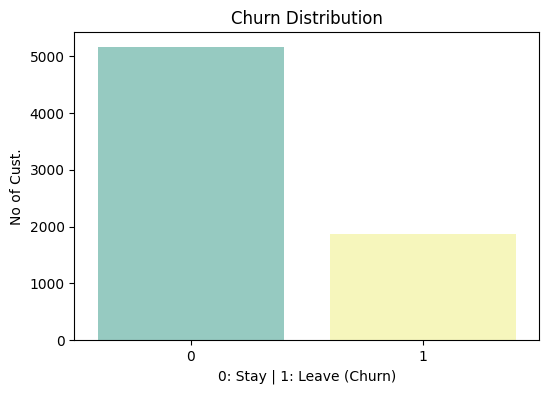

Churn Value
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [15]:
"Biggest problem in the data is unbalanced target sides"

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn Value', data=data, palette='Set3')
plt.title("Churn Distribution")
plt.xlabel("0: Stay | 1: Leave (Churn)")
plt.ylabel("No of Cust.")
plt.show()

print(data['Churn Value'].value_counts(normalize=True) * 100)

Comment: As we see above, there ara unbalanced amount between target segments

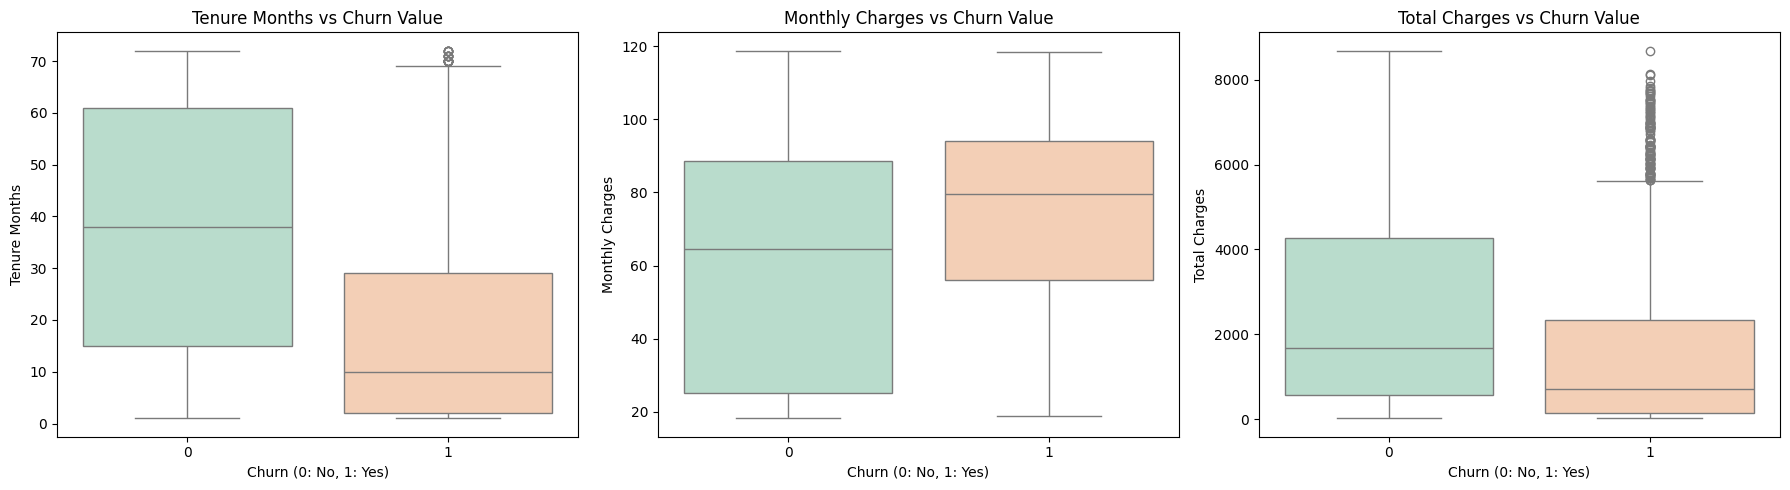

In [16]:
"We will investigate the columns those have numerical values and target variable relation"

num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(x="Churn Value", y=col, data=data, ax=axes[i], palette="Pastel2")
    axes[i].set_title(f"{col} vs Churn Value")
    axes[i].set_xlabel("Churn (0: No, 1: Yes)")

plt.tight_layout()
plt.show()

Comment: Lower tenure months has a relation with churn, other columns has similar characteristic with churn but I don't think
we have a clear sight so let's investigate more on same data

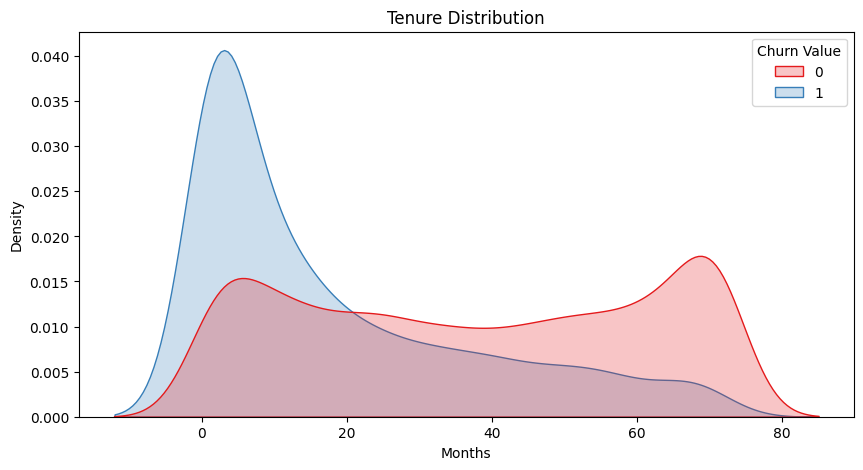

In [17]:
plt.figure(figsize=(10, 5))
# Density Graph - Tenure
sns.kdeplot(data=data, x="Tenure Months", hue="Churn Value", shade=True, palette="Set1", common_norm=False)
plt.title("Tenure Distribution")
plt.xlabel("Months")
plt.ylabel("Density")
plt.show()

This is better I guess

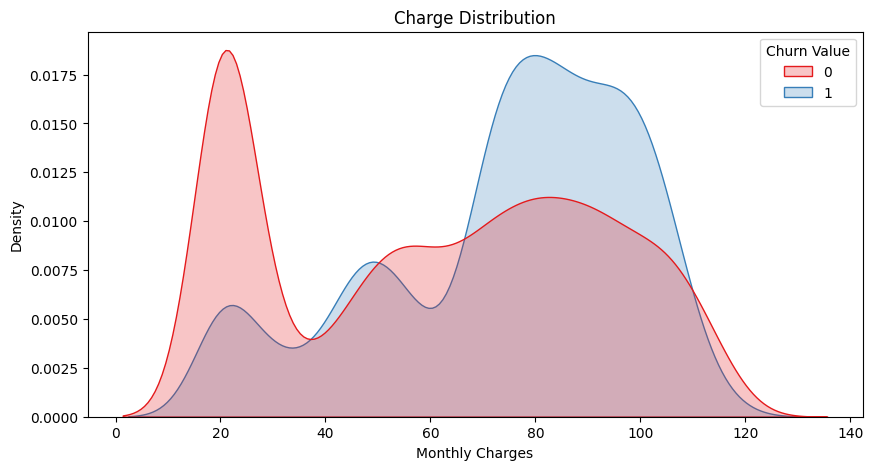

In [18]:
plt.figure(figsize=(10, 5))
# Density Graph - Monthly Charges
sns.kdeplot(data=data, x="Monthly Charges", hue="Churn Value", shade=True, palette="Set1", common_norm=False)
plt.title("Charge Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.show()

As expected, the charge amount has a direct impact on churn but exhibits a nonlinear characteristics decrease on 40 and 60), we may work on values before the analysis

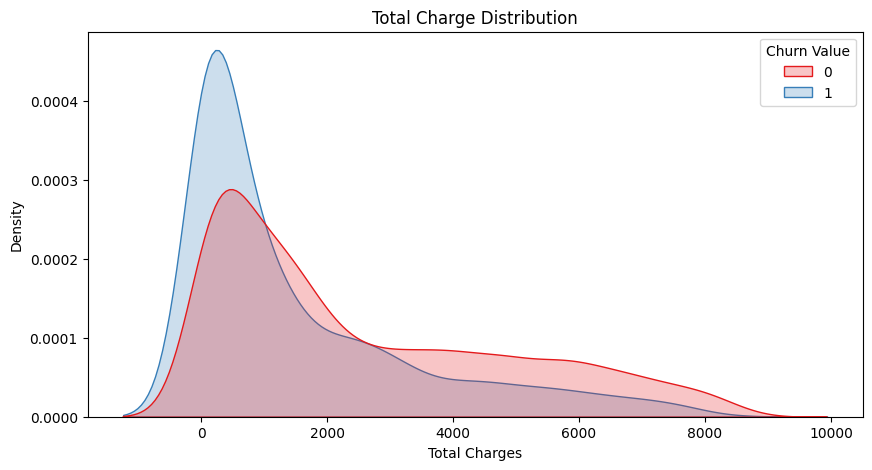

In [19]:
plt.figure(figsize=(10, 5))
# Density Graph - Total Charges
sns.kdeplot(data=data, x="Total Charges", hue="Churn Value", shade=True, palette="Set1", common_norm=False)
plt.title("Total Charge Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Density")
plt.show()

Churn realizes on lower Total Charges so as we figured out in Tenure graph new customers leave earlier.

I will not prefer to apply linear methods so I will not make a multicolinearity analysis on variables. It is obvious that total charge
is the result of tenure months*monthly charge but many ML algorthms can handle it

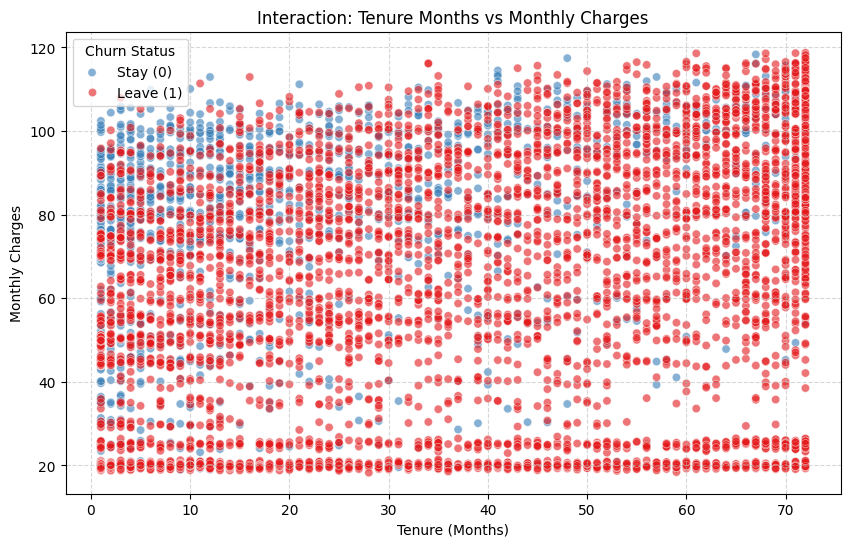

In [20]:
plt.subplots(figsize=(10, 6))
sns.scatterplot(data=data, x="Tenure Months", y="Monthly Charges", hue="Churn Value", alpha=0.6, palette="Set1")
plt.title("Interaction: Tenure Months vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.legend(title="Churn Status", labels=["Stay (0)", "Leave (1)"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_7400\4107936569.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
C:\Users\Asus\AppData\Local\Temp\ipykernel_7400\4107936569.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)


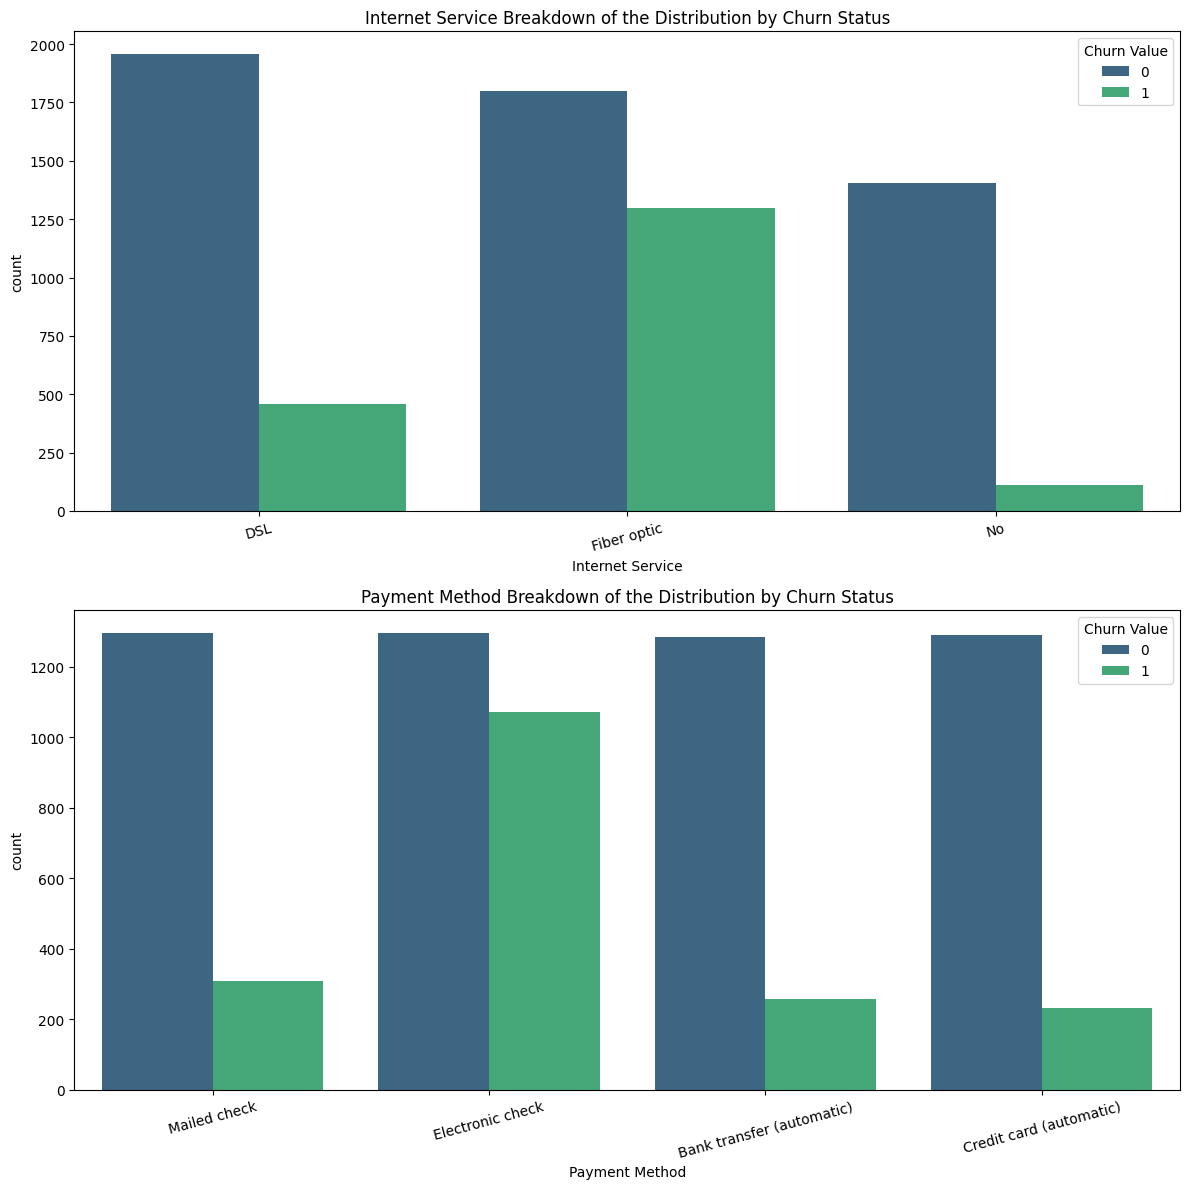

In [21]:
"Let's focus on other cathegorical variables"

cat_cols = ["Internet Service", "Payment Method"]

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn Value', data=data, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{col} Breakdown of the Distribution by Churn Status")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

It'is interesting that electronic check and fiber optic varies from others, I think these variables are good info sources for churn because it has much higher ratio compared to others, almost equal whether churn is 0 or 1

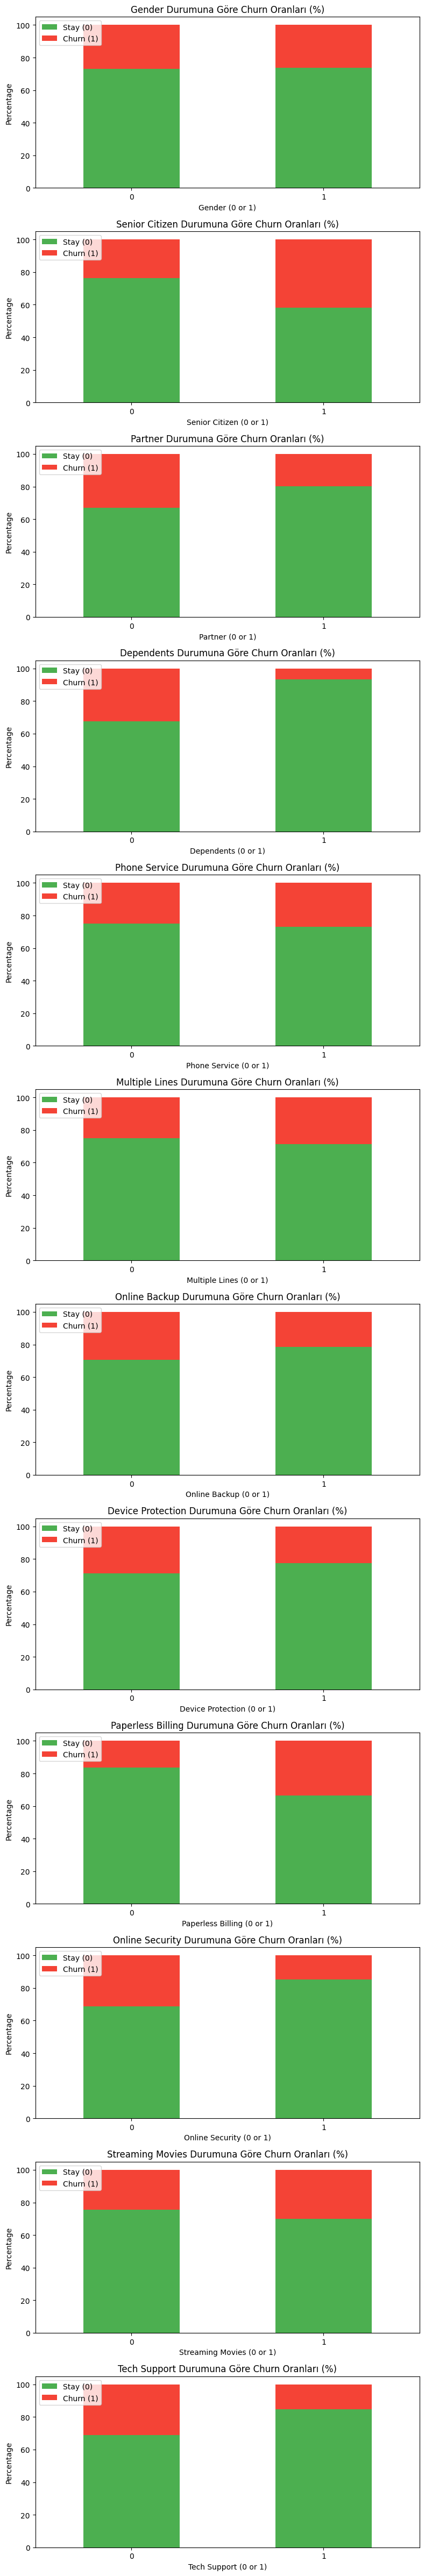

In [22]:
" Then we focus on binary columns"

binary_analyses_cols = ["Gender", "Senior Citizen", "Partner", "Dependents", "Phone Service", "Multiple Lines", "Online Backup", "Device Protection",
    "Paperless Billing", "Online Security", "Streaming", "Streaming Movies", "Tech Support"]

binary_analyses_cols = [col for col in binary_analyses_cols if col in data.columns]

fig, axes = plt.subplots(nrows=len(binary_analyses_cols), ncols=1, figsize=(8, 4 * len(binary_analyses_cols)))

if len(binary_analyses_cols) == 1:
    axes = [axes]

for i, col in enumerate(binary_analyses_cols):
    crosstab_pct = pd.crosstab(data[col], data['Churn Value'], normalize='index') * 100
    
    crosstab_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#4caf50', '#f44336'])
    axes[i].set_title(f"{col} Durumuna Göre Churn Oranları (%)")
    axes[i].set_ylabel("Percentage")
    axes[i].set_xlabel(f"{col} (0 or 1)")
    axes[i].legend(["Stay (0)", "Churn (1)"], loc='upper left')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

It seems that Senior Citizen and Paperless Billing columns differs on churn compared to other variables, good info

In [23]:
" We will apply chi-square test for the columns that has binary values"

from scipy.stats import chi2_contingency

target_variable="Churn Value"

cat_columns = [
    "Gender", "Senior Citizen", "Partner", "Dependents", 
    "Phone Service", "Multiple Lines", "Internet Service", 
    "Online Security", "Online Backup", "Device Protection", 
    "Tech Support", "Streaming TV", "Streaming Movies", 
    "Contract", "Paperless Billing", "Payment Method"]

cat_columns = [col for col in cat_columns if col in data.columns]

chi2_results = []

for col in cat_columns:
    
    contingency_table = pd.crosstab(data[col], data[target_variable])
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    
    is_significant = "Yes" if p_value < 0.05 else "No"
    
    chi2_results.append({
        "Variable": col,
        "chi2": round(chi2, 2),
        "p-value": f"{p_value:.6f}" if p_value > 0.000001 else "0.000000 (<0.001)",
        "Degree of Freedom": dof,
        "Significant (%5)": is_significant})

chi2_summary_df = pd.DataFrame(chi2_results)
chi2_summary_df = chi2_summary_df.sort_values(by="chi2", ascending=False).reset_index(drop=True)

chi2_summary_df

,Variable,chi2,p-value,Degree of Freedom,Significant (%5)
0,Contract,1179.55,0.000000 (<0.001),2,Yes
1,Internet Service,728.70,0.000000 (<0.001),2,Yes
2,Payment Method,645.43,0.000000 (<0.001),3,Yes
3,Dependents,431.65,0.000000 (<0.001),1,Yes
4,Paperless Billing,256.87,0.000000 (<0.001),1,Yes
5,Online Security,205.42,0.000000 (<0.001),1,Yes
6,Tech Support,189.97,0.000000 (<0.001),1,Yes
7,Senior Citizen,158.44,0.000000 (<0.001),1,Yes
8,Partner,157.50,0.000000 (<0.001),1,Yes
9,Online Backup,47.25,0.000000 (<0.001),1,Yes


Phone service and gender is denied by chi-square test, others performed well. Let's keep it in mind.

In [24]:
"We will use chi-square test for other categorical columns but more than 2 option need some modification - Cramer's V"

from scipy.stats import chi2_contingency

multi_cat = ["Internet Service", "Payment Method"] 
multi_cat = [col for col in multi_cat if col in data.columns]

target_variable = "Churn Value"
n = len(data)

for col in multi_cat:
    print(f"\n=================== {col.upper()} Analysis ===================")
    
    obs = pd.crosstab(data[col], data[target_variable])
    
    chi2, p_value, dof, expected = chi2_contingency(obs)
    
    cramers_v = np.sqrt(chi2 / n)
    
    print(f"Chi2 Score: {chi2:.2f}")
    print(f"P-Value: {p_value:.6f}")
    print(f"Cramer's V: {cramers_v:.3f} " + 
          ("(Strong)" if cramers_v > 0.25 else "(Medium)" if cramers_v > 0.10 else "(Weak)"))
    
    residuals = (obs - expected) / np.sqrt(expected)
    
    print("\n--- Categories Effect Churn - Residual Analysis ---")
    for category in residuals.index:
        churn_1_residual = residuals.loc[category, 1]
        if churn_1_residual > 2:
            print(f"-> [{category}]: Significantly higher churn rate compared to normal (Residual: {churn_1_residual:.2f})")
        elif churn_1_residual < -2:
            print(f"-> [{category}]: Significantly lower churn rate compared to normal-Loyal Customer (Residual: {churn_1_residual:.2f})")


=================== INTERNET SERVICE Analysis ===================
Chi2 Score: 728.70
P-Value: 0.000000
Cramer's V: 0.322 (Strong)

--- Categories Effect Churn - Residual Analysis ---
-> [DSL]: Significantly lower churn rate compared to normal-Loyal Customer (Residual: -7.23)
-> [Fiber optic]: Significantly higher churn rate compared to normal (Residual: 16.53)
-> [No]: Significantly lower churn rate compared to normal-Loyal Customer (Residual: -14.48)

=================== PAYMENT METHOD Analysis ===================
Chi2 Score: 645.43
P-Value: 0.000000
Cramer's V: 0.303 (Strong)

--- Categories Effect Churn - Residual Analysis ---
-> [Bank transfer (automatic)]: Significantly lower churn rate compared to normal-Loyal Customer (Residual: -7.50)
-> [Credit card (automatic)]: Significantly lower churn rate compared to normal-Loyal Customer (Residual: -8.57)
-> [Electronic check]: Significantly higher churn rate compared to normal (Residual: 17.65)
-> [Mailed check]: Significantly lower ch

--- 1. Group Based Desc. Stats. ---

--> Tenure Months Distribution of the Variable by Churn Status:


,count,mean,median,std,skew
Churn Value,,,,,
0,5163,37.65,38.0,24.08,-0.03
1,1869,17.98,10.0,19.53,1.15



--> Monthly Charges Distribution of the Variable by Churn Status:


,count,mean,median,std,skew
Churn Value,,,,,
0,5163,61.31,64.45,31.09,-0.03
1,1869,74.44,79.65,24.67,-0.73



--> Total Charges Distribution of the Variable by Churn Status:


,count,mean,median,std,skew
Churn Value,,,,,
0,5163,2555.34,1683.60,2329.46,0.81
1,1869,1531.80,703.55,1890.82,1.51



--- 2. MANN-WHITNEY Test Results ---


,Num_Var,U Stat,'p-value,Is distributions different (%5)
0,Tenure Months,7154668.0,0.000000 (<0.001),Yes
1,Monthly Charges,3663498.5,0.000000 (<0.001),Yes
2,Total Charges,6288982.0,0.000000 (<0.001),Yes



--- 3. SPEARMAN CORRELATION MATRIX (NON-LINEAR / MONOTONIC) ---


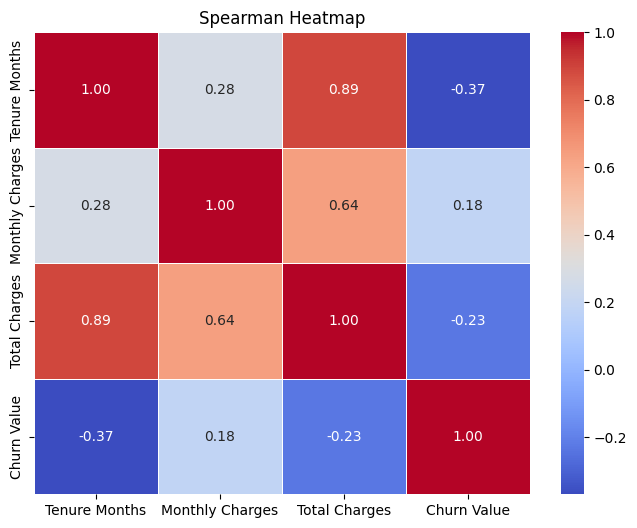

In [25]:
"""Finally we focus on the columns those have numerical values, we will analyze the values without modifying them (log transform, normalization etc.)
because of better interpretability choosing the correct transformation and distribution analysis"""

from scipy.stats import mannwhitneyu

target_variable = "Churn Value"
num_columns = ["Tenure Months", "Monthly Charges", "Total Charges"]

print("--- 1. Group Based Desc. Stats. ---")
for col in num_columns:
    print(f"\n--> {col} Distribution of the Variable by Churn Status:")
    summary = data.groupby(target_variable)[col].agg(["count", "mean", "median", "std", "skew"]).round(2)
    display(summary)

print("\n--- 2. MANN-WHITNEY Test Results ---")
mwu_results = []

for col in num_columns:
    group_stay = data[data[target_variable] == 0][col]
    group_churn = data[data[target_variable] == 1][col]
    
    stat, p_value = mannwhitneyu(group_stay, group_churn, alternative='two-sided')
    
    is_significant = "Yes" if p_value < 0.05 else "No"
    
    mwu_results.append({
        "Num_Var": col,
        "U Stat": round(stat, 2),
        "'p-value": f"{p_value:.6f}" if p_value > 0.000001 else "0.000000 (<0.001)",
        "Is distributions different (%5)": is_significant
    })

mwu_df = pd.DataFrame(mwu_results)
display(mwu_df)

print("\n--- 3. SPEARMAN CORRELATION MATRIX (NON-LINEAR / MONOTONIC) ---")
plt.figure(figsize=(8, 6))

spearman_corr = data[num_columns + [target_variable]].corr(method="spearman")

sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Heatmap")
plt.show()

- The descriptive statistics provide us the same info of the previous analysis, positive skewness of tenure period shows us that churn customers are
  early leavers company couldn't receive not more than 700 according to total charges. Also price also an important factor on churn.

- Non-normal distribution charteristics of variables forces us to use MANN-Whitney test instead of traditional t-test and all the variables
  exhibit meaningfull results. Provided information from descriptive statistics such as higher prices causes churn and newer customers exhibits
  higher churn possibility is proved by this test.

- For exhibiting the nonlinear interractions I have seleted Spearmen Correlation instead of Pearson Correlation. Most significant relationship
  is between churn value and tenure months (-0,37). The negative correlation value prove the fact that increasing customer period reduces the churn
  ratio.
- Monthly charges has positive relationship with churn value as we figured out before (0.18)

In [26]:
"I previously mentioned not to get rid of the total charges column but I think it is a wise choice to remove it"

data=data.drop("Total Charges", axis=1)
data

,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Churn Value
0,33.964131,-118.272783,1,0,0,0,2,1,0,DSL,...,1,0,0,0,0,0,1,Mailed check,53.85,1
1,34.059281,-118.307420,0,0,0,1,2,1,0,Fiber optic,...,0,0,0,0,0,0,1,Electronic check,70.70,1
2,34.048013,-118.293953,0,0,0,1,8,1,1,Fiber optic,...,0,1,0,1,1,0,1,Electronic check,99.65,1
3,34.062125,-118.315709,0,0,1,1,28,1,1,Fiber optic,...,0,1,1,1,1,0,1,Electronic check,104.80,1
4,34.039224,-118.266293,1,0,0,1,49,1,1,Fiber optic,...,1,1,0,1,1,0,1,Bank transfer (automatic),103.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,34.341737,-116.539416,0,0,0,0,72,1,0,No,...,0,0,0,0,0,2,1,Bank transfer (automatic),21.15,0
7039,34.667815,-117.536183,1,0,1,1,24,1,1,DSL,...,0,1,1,1,1,1,1,Mailed check,84.80,0
7040,34.559882,-115.637164,0,0,1,1,72,1,1,Fiber optic,...,1,1,0,1,1,1,1,Credit card (automatic),103.20,0
7041,34.167800,-116.864330,0,0,1,1,11,0,0,DSL,...,0,0,0,0,0,0,1,Electronic check,29.60,0


## 3- Evaluation of Model

I have prepared our data for analysis, in the first step I will split our data to into two parts, train and test. 
I will use a broader approach on algorithms, PyCaret is a good library for analyzing the data via many different algoritms"
I will also use MLFlow for development process of our project to demonstrate our results"

In [27]:
# Before starting the modelling, I will make feature extraction (engineering) for a better prediction performance
# Tenure months has an interesting information 
def create_tenure_cohort(tenure):
    if tenure <= 12:
        return "High_Risk (0-1 year)"
    elif tenure <= 24:
        return "Standard (1-2 year)"
    elif tenure <= 48:
        return "Loyal (2-4 year)"
    else:
        return "Good_Cust (4+ year)"

data['Tenure_Cohort'] = data['Tenure Months'].apply(create_tenure_cohort)

In [28]:
from sklearn.model_selection import train_test_split

X=data.drop("Churn Value", axis=1)
y=data["Churn Value"]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [29]:
import mlflow
from pycaret.classification import ClassificationExperiment

pycaret_train = pd.concat([X_train, y_train], axis=1)
pycaret_test = pd.concat([X_test, y_test], axis=1)

Pexp = ClassificationExperiment()

Pexp.setup(
    data=pycaret_train,           
    test_data=pycaret_test,       
    target="Churn Value",         
    fix_imbalance=True,
    normalize=True,
    normalize_method="zscore",
    encoding_method="default",
    n_jobs=1,
    fold_strategy="stratifiedkfold",
    fold=5,                       
    session_id=42,
    log_experiment=True,
    experiment_name="telco_churn_project",
    verbose=True)

model_comp_tab = Pexp.compare_models(sort="F1")

C:\Users\Asus\anaconda3\envs\datascience\lib\site-packages\mlflow\utils\autologging_utils\versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


,Description,Value
0,Session id,42
1,Target,Churn Value
2,Target type,Binary
3,Original data shape,"(7032, 22)"
4,Transformed data shape,"(9667, 30)"
5,Transformed train set shape,"(8260, 30)"
6,Transformed test set shape,"(1407, 30)"
7,Numeric features,18
8,Categorical features,3
9,Preprocess,True


2026/06/29 14:16:33 INFO mlflow.tracking.fluent: Experiment with name 'telco_churn_project' does not exist. Creating a new experiment.


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.7611,0.8580,0.8234,0.5328,0.6468,0.4786,0.5047,0.2300
lr,Logistic Regression,0.7648,0.8588,0.8033,0.5386,0.6448,0.4790,0.5005,0.4020
ridge,Ridge Classifier,0.7596,0.8581,0.8207,0.5310,0.6447,0.4755,0.5014,0.2200
ada,Ada Boost Classifier,0.7970,0.8587,0.6890,0.6042,0.6436,0.5026,0.5048,0.8820
nb,Naive Bayes,0.7755,0.8494,0.7532,0.5572,0.6404,0.4824,0.4941,0.2220
gbc,Gradient Boosting Classifier,0.8059,0.8594,0.6388,0.6336,0.6361,0.5037,0.5038,2.5120
svm,SVM - Linear Kernel,0.7474,0.8420,0.8067,0.5164,0.6295,0.4517,0.4777,0.3040
qda,Quadratic Discriminant Analysis,0.7634,0.8353,0.7177,0.5436,0.6162,0.4505,0.4619,0.2800
lightgbm,Light Gradient Boosting Machine,0.7991,0.8526,0.5666,0.6376,0.5999,0.4664,0.4679,0.5520
rf,Random Forest Classifier,0.7932,0.8434,0.5645,0.6222,0.5917,0.4538,0.4549,1.5960


In [30]:
# I coudn't achieve a huge performance improvement, so I will expect performance improvement by tuning
# For better explainability I choose logistic regression and blended model consist of top 3 models

lr_model = Pexp.create_model("lr")
tuned_lr = Pexp.tune_model(lr_model, optimize="F1")

lr_test_results = Pexp.predict_model(tuned_lr)

best3_models = Pexp.compare_models(n_select=3, sort="F1")

blended_m = [Pexp.tune_model(i, optimize="F1") for i in best3_models]

blended_model = Pexp.blend_models(estimator_list=blended_m, optimize="F1")

blended_test_results = Pexp.predict_model(blended_model)

Pexp.save_model(tuned_lr, "final_telco_lr_model")
Pexp.save_model(blended_model, "final_telco_blended_model")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7538,0.8587,0.8094,0.5238,0.6360,0.4626,0.4876
1,0.7769,0.8826,0.8328,0.5533,0.6649,0.5077,0.5315
2,0.7636,0.8556,0.8027,0.5369,0.6434,0.4768,0.4984
3,0.7502,0.8332,0.7525,0.5208,0.6156,0.4395,0.4559
4,0.7796,0.8640,0.8194,0.5581,0.6640,0.5086,0.5293
Mean,0.7648,0.8588,0.8033,0.5386,0.6448,0.4790,0.5005
Std,0.0118,0.0159,0.0274,0.0151,0.0185,0.0266,0.0281


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7547,0.8585,0.8127,0.5248,0.6378,0.4650,0.4904
1,0.7769,0.8825,0.8328,0.5533,0.6649,0.5077,0.5315
2,0.7644,0.8557,0.8027,0.5381,0.6443,0.4783,0.4997
3,0.7502,0.8333,0.7525,0.5208,0.6156,0.4395,0.4559
4,0.7769,0.8640,0.8161,0.5545,0.6604,0.5031,0.5239
Mean,0.7646,0.8588,0.8033,0.5383,0.6446,0.4787,0.5003
Std,0.0110,0.0158,0.0272,0.0140,0.0176,0.0251,0.0268


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7342,0.8390,0.7861,0.5000,0.6112,0.4241,0.4492


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.7611,0.8580,0.8234,0.5328,0.6468,0.4786,0.5047,0.2220
lr,Logistic Regression,0.7648,0.8588,0.8033,0.5386,0.6448,0.4790,0.5005,0.2400
ridge,Ridge Classifier,0.7596,0.8581,0.8207,0.5310,0.6447,0.4755,0.5014,0.2020
ada,Ada Boost Classifier,0.7970,0.8587,0.6890,0.6042,0.6436,0.5026,0.5048,0.7920
nb,Naive Bayes,0.7755,0.8494,0.7532,0.5572,0.6404,0.4824,0.4941,0.2100
gbc,Gradient Boosting Classifier,0.8059,0.8594,0.6388,0.6336,0.6361,0.5037,0.5038,2.4440
svm,SVM - Linear Kernel,0.7474,0.8420,0.8067,0.5164,0.6295,0.4517,0.4777,0.2620
qda,Quadratic Discriminant Analysis,0.7634,0.8353,0.7177,0.5436,0.6162,0.4505,0.4619,0.2340
lightgbm,Light Gradient Boosting Machine,0.7991,0.8526,0.5666,0.6376,0.5999,0.4664,0.4679,0.5560
rf,Random Forest Classifier,0.7932,0.8434,0.5645,0.6222,0.5917,0.4538,0.4549,1.5340


...

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7440,0.0000,0.8194,0.5115,0.6298,0.4497,0.4790
1,0.7787,0.0000,0.8528,0.5543,0.6719,0.5160,0.5433
2,0.7618,0.0000,0.8227,0.5336,0.6474,0.4796,0.5052
3,0.7449,0.0000,0.7525,0.5137,0.6106,0.4308,0.4481
4,0.7769,0.0000,0.8428,0.5526,0.6675,0.5103,0.5361
Mean,0.7612,0.0000,0.8181,0.5332,0.6455,0.4773,0.5023
Std,0.0149,0.0000,0.0351,0.0183,0.0230,0.0332,0.0355


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.7292,0.7508,0.7968,0.4942,0.6100,0.4196,0.4477


Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Latitude', 'Longitude', 'Gender',
                                              'Senior Citizen', 'Partner',
                                              'Dependents', 'Tenure Months',
                                              'Phone Service', 'Multiple Lines',
                                              'Online Security', 'Online Backup',
                                              'Device Protection',
                                              'Tech Support', 'Streaming TV',
                                              'Streaming Movies', 'Contract',
                                              'Paperless Billing'...
                                                                   n_jobs=None,
                                                                   penalty='l2',
                     

Accually I am a little bit disappointed with the performance of stacked model. I used logistic regression and a blended model with 3 best performing algorithms but it seems that both models overfit according to performance metrics so I will continue with the base logistic regression model using "Ockham's razor" approach.

In [31]:
final_lr_model = Pexp.create_model("lr")

final_test_results = Pexp.predict_model(tuned_lr)

Pexp.save_model(tuned_lr, "final_telco_churn_model")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7538,0.8587,0.8094,0.5238,0.6360,0.4626,0.4876
1,0.7769,0.8826,0.8328,0.5533,0.6649,0.5077,0.5315
2,0.7636,0.8556,0.8027,0.5369,0.6434,0.4768,0.4984
3,0.7502,0.8332,0.7525,0.5208,0.6156,0.4395,0.4559
4,0.7796,0.8640,0.8194,0.5581,0.6640,0.5086,0.5293
Mean,0.7648,0.8588,0.8033,0.5386,0.6448,0.4790,0.5005
Std,0.0118,0.0159,0.0274,0.0151,0.0185,0.0266,0.0281


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7342,0.8390,0.7861,0.5000,0.6112,0.4241,0.4492


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Latitude', 'Longitude', 'Gender',
                                              'Senior Citizen', 'Partner',
                                              'Dependents', 'Tenure Months',
                                              'Phone Service', 'Multiple Lines',
                                              'Online Security', 'Online Backup',
                                              'Device Protection',
                                              'Tech Support', 'Streaming TV',
                                              'Streaming Movies', 'Contract',
                                              'Paperless Billing'...
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
              

At least I have reached to %79 recall performance so almost 80 percent of leaving customers are detected.

## 4-Features

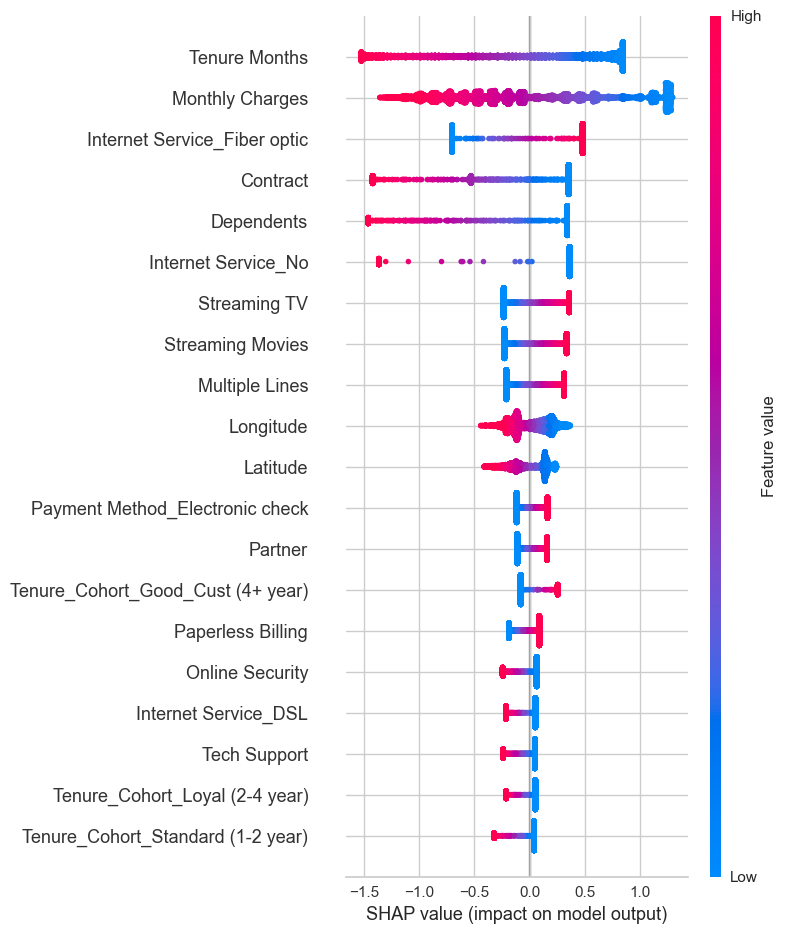

In [32]:
"In this section, independent variables effects will be shown"

import shap
import matplotlib.pyplot as plt

X_train_transformed = Pexp.get_config("X_train_transformed")

if hasattr(tuned_lr, "steps"):
    actual_lr_model = tuned_lr.steps[-1][1]
else:
    actual_lr_model = tuned_lr

explainer = shap.LinearExplainer(actual_lr_model, X_train_transformed)
shap_values = explainer.shap_values(X_train_transformed)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_train_transformed)
plt.show()

In [33]:
# A confusing plot so let's switch it to numbers

mean_shap_values = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature": X_train_transformed.columns,
    "Mean_SHAP_Impact": mean_shap_values
})

shap_df = shap_df.sort_values(by="Mean_SHAP_Impact", ascending=False).reset_index(drop=True)

display(shap_df)

,Feature,Mean_SHAP_Impact
0,Tenure Months,0.700253
1,Monthly Charges,0.656164
2,Internet Service_Fiber optic,0.583527
3,Contract,0.559137
4,Dependents,0.528651
5,Internet Service_No,0.527518
6,Streaming TV,0.276187
7,Streaming Movies,0.263690
8,Multiple Lines,0.245860
9,Longitude,0.152931


## 5-Financial Analysis

In [34]:
# Let's make a financial analysis
""" For financial analysis I used EDA values for making assumptions. I have assumed an average 65 dolars income with 20 dolars promotion/discount
and average 12 months additional stay with %20 conversion on churn customers"""

preds = final_test_results

TP = len(preds[(preds["Churn Value"] == 1) & (preds["prediction_label"] == 1)])
FP = len(preds[(preds["Churn Value"] == 0) & (preds["prediction_label"] == 1)])
FN = len(preds[(preds["Churn Value"] == 1) & (preds["prediction_label"] == 0)])

avg_revenue = 65
retention_cost = 20
months_saved = 12
conversion_rate = 0.20

total_campaign_cost = (TP + FP) * retention_cost

total_revenue_saved = (TP * conversion_rate) * (avg_revenue * months_saved)

net_profit = total_revenue_saved - total_campaign_cost

print(f"--- Financial Simulation on Test data ({len(preds)} customers) ---")
print(f"-> Detected Churns (TP): {TP} customer (Targeted for retention)")
print(f"-> False Alarm (FP): {FP} customer (Unnecessary promotion cost)")
print(f"-> Undetected Churns (FN): {FN} customer (Lost revenue)")
print("-" * 55)
print(f" Promotion Cost (for all predicted): -${total_campaign_cost:,.2f}")
print(f" Revenue from persuaded customers (20% conversion): +${total_revenue_saved:,.2f}")
print(f" Net Balance (Profit/Loss): ${net_profit:,.2f}")

--- Financial Simulation on Test data (1407 customers) ---
-> Detected Churns (TP): 294 customer (Targeted for retention)
-> False Alarm (FP): 294 customer (Unnecessary promotion cost)
-> Undetected Churns (FN): 80 customer (Lost revenue)
-------------------------------------------------------
 Promotion Cost (for all predicted): -$11,760.00
 Revenue from persuaded customers (20% conversion): +$45,864.00
 Net Balance (Profit/Loss): $34,104.00


Our prediction with average values showed that we will retain and addional 34.1 k income using this algorthm.